# Importing Required Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Upload Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Potato.zip to Potato (1).zip


# Dataset Path Set

In [ ]:
data_dir = "/content/potato_data/Potato_Dataset"

# Required Libraries Import

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Image Size & Batch Size

In [ ]:
import tensorflow as tf

img_size = (224, 224)
batch_size = 32

data_dir = '/content/Train'

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

Found 5702 files belonging to 3 classes.
Using 4562 files for training.
Found 5702 files belonging to 3 classes.
Using 1140 files for validation.


# Data Augmentation

In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
])


# CNN Model Build

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(224, 224, 3)),

    data_augmentation,
    normalization_layer,

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

# Compile Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 432s 3s/step - accuracy: 0.7413 - loss: 0.9922 - val_accuracy: 0.8816 - val_loss: 0.3127
Epoch 2/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 415s 3s/step - accuracy: 0.9020 - loss: 0.2557 - val_accuracy: 0.9167 - val_loss: 0.1974
Epoch 3/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 418s 3s/step - accuracy: 0.9443 - loss: 0.1418 - val_accuracy: 0.9465 - val_loss: 0.1354
Epoch 4/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 449s 3s/step - accuracy: 0.9557 - loss: 0.1183 - val_accuracy: 0.9491 - val_loss: 0.1336
Epoch 5/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 433s 3s/step - accuracy: 0.9599 - loss: 0.1124 - val_accuracy: 0.9640 - val_loss: 0.0992
Epoch 6/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 440s 3s/step - accuracy: 0.9698 - loss: 0.0814 - val_accuracy: 0.9605 - val_loss: 0.1097
Epoch 7/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 422s 3s/step - accuracy: 0.9603 - loss: 0.1082 - val_accuracy: 0.9395 - val_loss: 0.1813
Epoch 8/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 427s 3s/step - accuracy: 0.9693 - loss: 0.0846 - val_accu

# Model Evaluation

In [ ]:
loss, acc = model.evaluate(val_ds)
print("Accuracy:", acc)

36/36 ━━━━━━━━━━━━━━━━━━━━ 24s 670ms/step - accuracy: 0.9561 - loss: 0.1316
Accuracy: 0.9561403393745422


# Performance Visualization (Accuracy & Loss Graph)



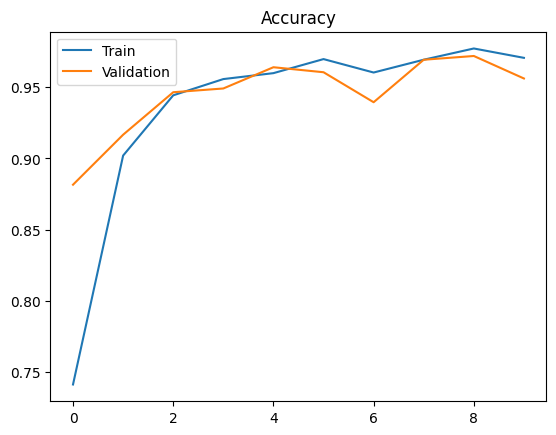

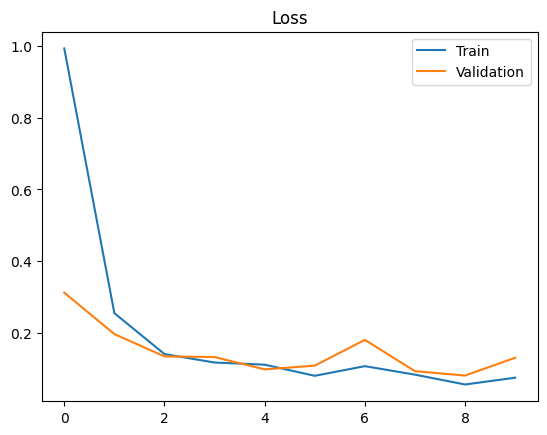

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title('Accuracy')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train', 'Validation'])
plt.title('Loss')
plt.show()